## Генеративно-состязательный нейронные сети GAN

### 1. Проблемы VAE

Рассмотренный вариационный автоэнкодер способен формировать компактное скрытое пространство и генерировать на его основе выходной сигнал, в частности, изображения цифр. И для решения этой задачи задаются два критерия: дивергенция Кульбака-Лейблера (для формирования желаемой формы ПРВ точек скрытого пространства) и квадрат рассогласования между входным и выходным изображениями. Именно этот второй критерий «заставлял» декодер восстанавливать сигнал близкий к входному:

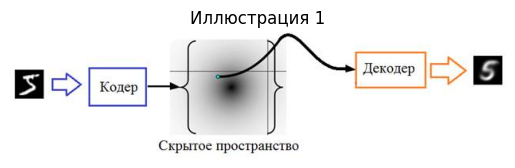

In [1]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

image1 = mpimg.imread('illustrations/VAE_generation_1.jpg')

plt.imshow(image1)
plt.axis('off')
plt.title('Иллюстрация 1')
plt.show()

Однако изображения на выходе получались смазанными. Любая НС в процессе обучения старается уловить, сформировать закономерности между входными и выходными данными так, чтобы минимизировать заданный критерий. Теперь представьте, что у нас есть множество похожих пятерок и декодер для них должен сформировать адекватный ответ:

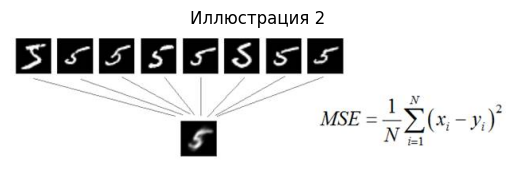

In [2]:
image2 = mpimg.imread('illustrations/VAE_generation_2.jpg')

plt.imshow(image2)
plt.axis('off')
plt.title('Иллюстрация 2')
plt.show()

Именно такая сглаженная пятерка будет удовлетворять минимуму среднего квадрата ошибки рассогласования между всеми этими входами. Но, в данном случае, результат не совсем такой, какой бы мы хотели. Было бы куда лучше иметь нормальное, четкое изображение цифры, пусть даже с бОльшим значением показателя MSE.

В 2014-м году Ян Гудфеллоу (Ian Goodfellow) предложил новую концепцию, известную сейчас под названием генеративно-состязательные сети (Generative Adversarial Networks). Ключевая идея заключается в формировании критерия качества для генератора с помощью еще одной НС: